# Spotify Tracks Analysis: Do Audio Features Really Drive Popularity?

**Objective:** It is expected that musical features of a song (such as its energy, loudness, danceability etc) drive its popularity. But does that actually happen in the real world? Or, are there factors, beyond the audio features, that influence song's popularity?

**Aim:** Evaluate whether intrinsic audio features meaningfully explain song popularity on Spotify.

**Key Questions:**
1. Do audio features show statistically meaningful relationships with popularity?
2. Do popular songs exhibit distinct feature patterns compared to less popular ones?
3. If explanatory power is limited, what does this suggest about external drivers of popularity?

## 1. Setup & Data Loading

In [285]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [286]:
df=pd.read_csv("dataset.csv")
print(f"Dataset loaded: {df.shape[0]:,} tracks, {df.shape[1]} features")
df.head(3)

Dataset loaded: 114,000 tracks, 21 features


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,...,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,...,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


## 2. Initial Data Understanding

**Evaluate:**
- Data types and structure
- Missing values patterns
- Distribution of key variables
- Potential data quality issues

In [287]:
# Comprehensive data overview
def data_overview(df):
    print("="*70)
    print("DATA QUALITY REPORT")
    print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print("\nMissing Values:")
    missing= df.isnull().sum()
    missing_pct =((missing/len(df))*100).round(2)
    missing_df =pd.DataFrame({'Missing_Count': missing[missing>0],'Percentage': missing_pct[missing> 0]}).sort_values('Percentage', ascending=False)
    if len(missing_df)>0:
        print(missing_df)
    else:
        print("No missing values detected")
    dup_rows=df[df.duplicated()]
    duplicates=len(dup_rows)
    print(f"\nNumber of duplicate rows: {duplicates} (i.e., {duplicates/len(df)*100:.2f}%)")
    if duplicates>0:
        print("\nSample duplicate rows:")
        print(dup_rows.head(10))
    print("\nData Types:")
    print(df.dtypes.value_counts())
    print("\n" + "="*70)
data_overview(df)

DATA QUALITY REPORT
Dataset Shape: 114000 rows × 21 columns

Missing Values:
            Missing_Count  Percentage
artists                 1         0.0
album_name              1         0.0
track_name              1         0.0

Number of duplicate rows: 0 (i.e., 0.00%)

Data Types:
float64    9
int64      6
str        5
bool       1
Name: count, dtype: int64



In [288]:
# Define feature groups for analysis
audio_features =['danceability','energy','key','loudness','mode','speechiness','acousticness','instrumentalness','liveness','valence','tempo']
metadata_features=['artists', 'album_name','track_name','track_genre','track_id','duration_ms','explicit','time_signature']
target_variable ='popularity'
print("="*60)
print("Feature categories defined:")
print(f"Audio features: {len(audio_features)}")
print(f"Metadata features: {len(metadata_features)}")
print(f"Target: {target_variable}")
print("="*60)

Feature categories defined:
Audio features: 11
Metadata features: 8
Target: popularity


## 3. Data Cleaning & Feature Engineering

**Why this matters:** Raw data often needs transformation to reveal patterns<br>
**Approach:**
- Handle missing values
- Create derived features (duration in minutes, popularity categories)
- Detect and document outliers

In [289]:
df_clean=df.copy()
df_clean=df_clean.drop(columns=['Unnamed: 0'])
df_clean['duration_min']=df_clean['duration_ms'] / 60000
df_clean['popularity_category']=pd.cut(df_clean['popularity'],bins=[0,25, 50,75,100],labels=['Low','Medium', 'High','Very High'],include_lowest=True)
df_clean['explicit'] =df_clean['explicit'].astype(int)
print("="*60)
print(f"New features created:")
print(f"duration_min: Continuous (minutes)")
print(f"popularity_category: Categorical (4 levels)")
print(f"\nPopularity distribution:")
print(df_clean['popularity_category'].value_counts().sort_index())
print("="*60)

New features created:
duration_min: Continuous (minutes)
popularity_category: Categorical (4 levels)

Popularity distribution:
popularity_category
Low          44424
Medium       41806
High         25356
Very High     2414
Name: count, dtype: int64


In [60]:
df_clean.select_dtypes(include='number').agg(['min', 'max'])

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_min
min,0,0,0,0.000,0.0,0,-49.531,0,0.000,0.000,0.0,0.0,0.000,0.000,0,0.00000
max,100,5237295,1,0.985,1.0,11,4.532,1,0.965,0.996,1.0,1.0,0.995,243.372,5,87.28825


In [290]:
def detect_outliers_iqr(df, column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3- Q1
    lower_bound=Q1-1.5* IQR
    upper_bound=Q3 +1.5*IQR
    outliers =df[(df[column]<lower_bound) | (df[column]>upper_bound)]
    return len(outliers),(len(outliers)/len(df) *100)
print("="*60)
print("Outlier Analysis (IQR method):")
for feature in ['duration_min', 'tempo', 'loudness']: 
    count,pct=detect_outliers_iqr(df_clean,feature)
    print(f"{feature:15}: {count:3} outliers ({pct:5.2f}%)")
print("\nDecision: Keeping outliers for now - they may represent genuine edge cases")
print("(e.g., very long classical pieces, experimental tempo tracks)")
print("="*60)

Outlier Analysis (IQR method):
duration_min   : 5618 outliers ( 4.93%)
tempo          : 617 outliers ( 0.54%)
loudness       : 6173 outliers ( 5.41%)

Decision: Keeping outliers for now - they may represent genuine edge cases
(e.g., very long classical pieces, experimental tempo tracks)


## 4. Univariate Analysis: Understanding Individual Variables

**Key Question:** What does the distribution of each variable tells?<br>
**Why this matters:** Distributions reveal:
- Central tendencies (mean, median)
- Spread and variability
- Skewness and potential transformations needed
- Data quality issues

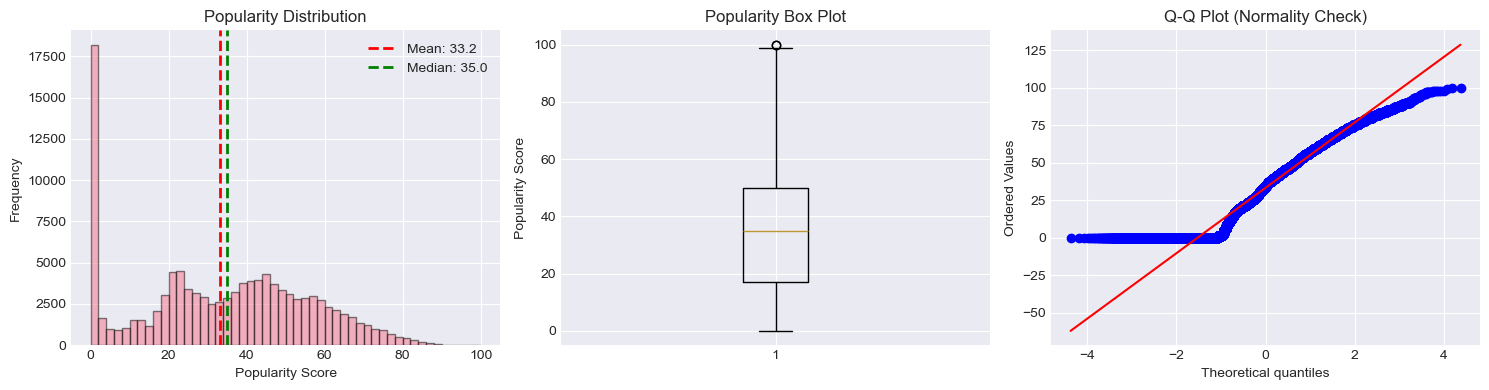

Popularity Statistics:

count    114000.000000
mean         33.238535
std          22.305078
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64

Skewness: 0.046
Kurtosis: -0.928


In [291]:
fig=plt.figure(figsize=(15,4))
axes=fig.subplots(1, 3)
axes[0].hist(df_clean['popularity'],bins=50,edgecolor='black',alpha=0.5)
axes[0].axvline(df_clean['popularity'].mean(),color='red',linestyle='--',linewidth=2,label=f'Mean: {df_clean["popularity"].mean():.1f}')
axes[0].axvline(df_clean['popularity'].median(), color='green',linestyle='--',linewidth=2,label=f'Median: {df_clean["popularity"].median():.1f}')
axes[0].set_xlabel('Popularity Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Popularity Distribution')
axes[0].legend()
axes[1].boxplot(df_clean['popularity'])
axes[1].set_ylabel('Popularity Score')
axes[1].set_title('Popularity Box Plot')
stats.probplot(df_clean['popularity'],dist="norm",plot=axes[2])
axes[2].set_title('Q-Q Plot (Normality Check)')
plt.tight_layout()
plt.show()
print("="*50)
print("Popularity Statistics:\n")
print(df_clean['popularity'].describe())
print(f"\nSkewness: {df_clean['popularity'].skew():.3f}")
print(f"Kurtosis: {df_clean['popularity'].kurtosis():.3f}")
print("="*50)

**Summary**
* The histogram is not bell-shaped, and the Q-Q plot shows strong deviation from the normal line, confirming that normality is violated.
* A significant spike at popularity = 0 indicates that a large portion of songs receive no engagement. This is not random noise but represents a distinct behavioral segment.<br>
* The dataset effectively consists of:
    - Songs with no engagement (0 popularity)<br>
    - Songs with varying levels of popularity<br>
* Mean ≈ 33, Median ≈ 35, Skew ≈ 0.05
    - This suggests symmetric distribution but it is misleading.<br>
    - Right tail pulls the skew but massive zero-inflation brings it back.<br>
    - Thus, statistics fail to capture the true non-symmetric structure of the feature.

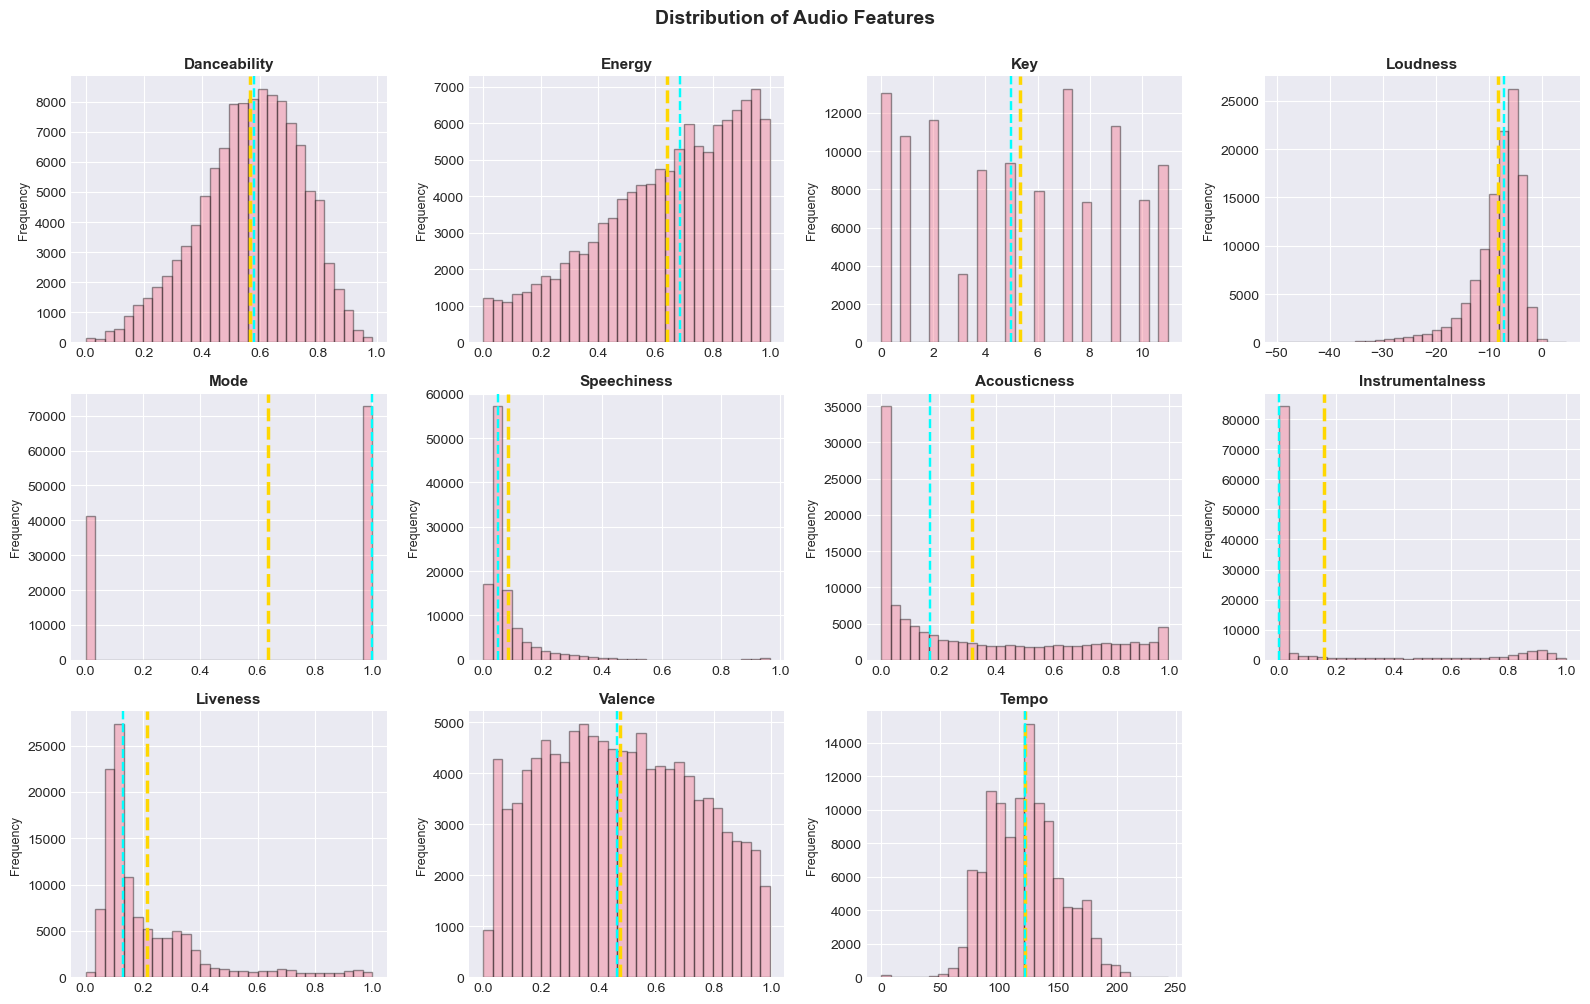

In [292]:
fig=plt.figure(figsize=(16,10))
axes=fig.subplots(3,4)
axes=axes.ravel()
for (idx, feature) in enumerate(audio_features):
    axes[idx].hist(df_clean[feature], bins=30, edgecolor='black', alpha=0.4)
    axes[idx].set_title(f'{feature.capitalize()}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('Frequency', fontsize=9)
    axes[idx].axvline(df_clean[feature].mean(),color='gold',linestyle='--',linewidth=2.5,alpha=1.0)
    axes[idx].axvline(df_clean[feature].median(),color='cyan',linestyle='--',linewidth=1.75, alpha=1.0)
fig.delaxes(axes[-1])
plt.suptitle('Distribution of Audio Features',fontsize=14,fontweight='bold',y= 1.00)
plt.tight_layout()
plt.show()

**Summary** <br>
- Many features are clustered or skewed, meaning they describe common production patterns.<br>
- Only a few (like valence, energy, danceability) show enough variation to potentially explain differences in popularity.

## 5. Bivariate Analysis: Audio Features vs Popularity

**Question:** Which audio features are associated with popularity?<br>
**Hypothesis:** Audio features are expected to exhibit varying degrees of association with popularity.

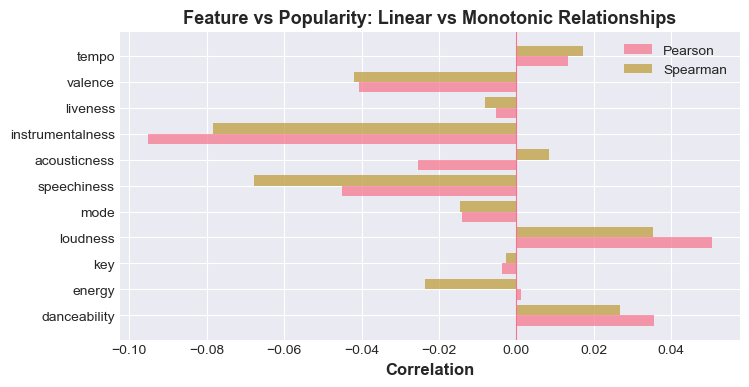

Correlation Analysis Results:

         Feature  Pearson_r  Spearman_r       Pearson_p       Spearman_p
    danceability   0.035448    0.026628    4.963399e-33     2.420897e-19
          energy   0.001056   -0.023513    7.213996e-01     2.022408e-15
             key  -0.003853   -0.002590    1.932703e-01     3.818181e-01
        loudness   0.050423    0.035178    4.484650e-65     1.483671e-32
            mode  -0.013931   -0.014501    2.554240e-06     9.757698e-07
     speechiness  -0.044927   -0.067872    5.064981e-52    1.751123e-116
    acousticness  -0.025472    0.008399    7.849077e-18     4.569626e-03
instrumentalness  -0.095139   -0.078454   2.047789e-227    4.420317e-155
        liveness  -0.005387   -0.008189    6.892581e-02     5.692872e-03
         valence  -0.040534   -0.041902    1.142394e-42     1.771875e-45
           tempo   0.013205    0.017085    8.251525e-06     7.975381e-09


In [96]:
def correlation_analysis(df,features,target):
    results=[]   
    for feature in features:
        data=df[[feature,target]].dropna()
        if len(data)<2:
            continue        
        p_corr,p_pval=stats.pearsonr(data[feature], data[target])
        s_corr, s_pval=stats.spearmanr(data[feature],data[target])       
        results.append({'Feature': feature,'Pearson_r': p_corr,'Spearman_r': s_corr,'Pearson_p': p_pval, 'Spearman_p': s_pval})    
    return pd.DataFrame(results)
corr_results = correlation_analysis(df_clean, audio_features, 'popularity')
plt.figure(figsize=(8,4))
y_pos=np.arange(len(corr_results))
bar_width=0.4
plt.barh(y_pos -bar_width/2,corr_results['Pearson_r'],height=bar_width,label='Pearson',alpha=0.7)
plt.barh(y_pos+bar_width/2,corr_results['Spearman_r'], height=bar_width, label='Spearman',alpha=0.7)
plt.yticks(y_pos,corr_results['Feature'])
plt.axvline(0,linewidth=0.8)
plt.xlabel('Correlation', fontsize=12,fontweight='bold')
plt.title('Feature vs Popularity: Linear vs Monotonic Relationships', fontsize=13, fontweight='bold')
plt.legend(loc='upper right')
plt.show()
print("="*80)
print("Correlation Analysis Results:\n")
print(corr_results.to_string(index=False,col_space={'Pearson_p': 15,'Spearman_p': 16}))
print("="*80)

**Summary**
- No single feature appears to strongly drive popularity alone as most audio features show negligible to weak individual relationships with popularity
- The effect size of all audio features is very small which suggests weak relationships despite having varying p-values.
- Magnitudes of Pearson and Spearman correlations indicate that both linear and monotonic relationships are weak
- Simillar correlation coeffients of Pearson and Spearman show there is no strong evidence of hidden non-linear monotonic patterns (eg. exponential)
- Run FDR to eliminate false inflation of p-values happened due to MTI (Multiple Test Inflation)

In [250]:
from statsmodels.stats.multitest import multipletests
def apply_fdr(corr_df):
    _,pearson_p_adj, _, _ =multipletests( corr_df['Pearson_p'],method='fdr_bh')
    _,spearman_p_adj, _, _ =multipletests(corr_df['Spearman_p'], method='fdr_bh')
    corr_df=corr_df.copy()
    corr_df['Pearson_p_adj']=pearson_p_adj
    corr_df['Spearman_p_adj']= spearman_p_adj
    return corr_df
corr_results=correlation_analysis(df_clean, audio_features, 'popularity')
corr_results2=apply_fdr(corr_results)
corr_results2['P_practical_significance']=( (corr_results2['Pearson_p_adj']<0.05) &(corr_results2['Pearson_r'].abs()>0.1))
corr_results2['S_practical_significance'] = ((corr_results2['Spearman_p_adj']< 0.05) &(corr_results2['Spearman_r'].abs()>0.1))
print("="*100 + "\nCorrelation Analysis: FDR & Practical Significance:\n")
print(corr_results2[['Feature','Pearson_r', 'Pearson_p_adj', 'P_practical_significance','Spearman_r', 'Spearman_p_adj', 'S_practical_significance']].to_string(index=False))
print("\nCriteria:")
print("Statistical threshold: p < 0.05\nPractical threshold: |r| > 0.10")
print("="*100)

Correlation Analysis: FDR & Practical Significance:

         Feature  Pearson_r  Pearson_p_adj  P_practical_significance  Spearman_r  Spearman_p_adj  S_practical_significance
    danceability   0.035448   1.091948e-32                     False    0.026628    5.325973e-19                     False
          energy   0.001056   7.213996e-01                     False   -0.023513    3.707748e-15                     False
             key  -0.003853   2.125974e-01                     False   -0.002590    3.818181e-01                     False
        loudness   0.050423   2.466558e-64                     False    0.035178    4.080096e-32                     False
            mode  -0.013931   4.013805e-06                     False   -0.014501    1.341683e-06                     False
     speechiness  -0.044927   1.857160e-51                     False   -0.067872   9.631174e-116                     False
    acousticness  -0.025472   1.438998e-17                     False    0.008399    5.

**Summary**
- Although many audio features show statistically significant relationships with popularity, their effect sizes are very small (|r| < 0.1), indicating that no single feature strongly explains popularity. Hence, individual audio features do not meaningfully drive popularity.
- This suggests that popularity might be driven by a combination of factors but definittely not by individual audio characteristics.

## 6. Hypothesis Testing: Do Popular Songs Sound Different?

**Question:** Are audio features of popular songs significantly different from unpopular songs?<br>
**Method:** Independent t-tests comparing high vs low popularity groups<br>
**Null Hypothesis (H₀):** No difference in audio features between popular and unpopular songs<br> 
**Alternative Hypothesis (H₁):** Meaningful differences exist

In [200]:
from statsmodels.stats.multitest import multipletests
popularity_threshold_high=df_clean['popularity'].quantile(0.75)
popularity_threshold_low=df_clean['popularity'].quantile(0.25)
popular_songs= df_clean[df_clean['popularity']>=popularity_threshold_high]
unpopular_songs=df_clean[df_clean['popularity'] <=popularity_threshold_low]
print("="*125)
print(f"Popular songs (top 25%): {len(popular_songs)} tracks (≥ {popularity_threshold_high:.0f})")
print(f"Unpopular songs (bottom 25%): {len(unpopular_songs)} tracks (≤ {popularity_threshold_low:.0f})")
hypothesis_results = []
for feature in audio_features:
    popular_values=popular_songs[feature].dropna()
    unpopular_values=unpopular_songs[feature].dropna()
    if len(popular_values)<2 or len(unpopular_values)< 2:
        continue
    t_stat, p_value=stats.ttest_ind(popular_values, unpopular_values, equal_var=False)
    mean_pop=popular_values.mean()
    mean_unpop=unpopular_values.mean()
    mean_diff  =mean_pop - mean_unpop
    std_pop=popular_values.std()
    std_unpop=unpopular_values.std()
    pooled_std =np.sqrt((std_pop**2 + std_unpop**2)/2)
    cohens_d=mean_diff /pooled_std if pooled_std!=0 else 0
    hypothesis_results.append({'Feature': feature,'Popular_Mean': mean_pop,'Unpopular_Mean': mean_unpop,'Mean_Diff': mean_diff,'T-Statistic': t_stat,'P-Value': p_value,'Cohens_d': cohens_d})
hyp_df=pd.DataFrame(hypothesis_results)
_, p_adj, _, _= multipletests(hyp_df['P-Value'],method='fdr_bh')
hyp_df['P_adj']= p_adj
hyp_df['Abs_d']= hyp_df['Cohens_d'].abs()
hyp_df['Effect_Size']=hyp_df['Abs_d'].apply(
    lambda x: 'Large' if x> 0.8 else'Medium' if x>0.5 else'Small' if x>0.2 else'Negligible')
hyp_df['Meaningful'] = np.where( (hyp_df['P_adj']<0.05) &(hyp_df['Abs_d']>0.2),'Yes', 'No')
hyp_df=  hyp_df.sort_values('Abs_d', ascending=False)
print("="*125)
print("HYPOTHESIS TESTING: Popular vs Unpopular Songs\n")
print(hyp_df.to_string(index=False))
print("\nCriteria:")
print("Statistical threshold: FDR-adjusted p < 0.05")
print("Practical threshold: Cohen's d > 0.2")
print("="*125)

Popular songs (top 25%): 29367 tracks (≥ 50)
Unpopular songs (bottom 25%): 29000 tracks (≤ 17)
HYPOTHESIS TESTING: Popular vs Unpopular Songs

         Feature  Popular_Mean  Unpopular_Mean  Mean_Diff  T-Statistic       P-Value  Cohens_d         P_adj    Abs_d Effect_Size Meaningful
instrumentalness      0.114527        0.196223  -0.081696   -32.230278 8.522422e-226 -0.267018 9.374664e-225 0.267018       Small        Yes
         valence      0.452860        0.491858  -0.038998   -18.617200  3.928168e-77 -0.154172  2.160493e-76 0.154172  Negligible         No
        loudness     -7.973963       -8.433833   0.459869    10.781859  4.447403e-27  0.089263  1.630714e-26 0.089263  Negligible         No
     speechiness      0.075214        0.079978  -0.004764    -7.542627  4.672531e-14 -0.062445  1.284946e-13 0.062445  Negligible         No
           tempo    121.584891      120.783772   0.801119     3.297978  9.744200e-04  0.027304  2.143724e-03 0.027304  Negligible         No
           

**Summary**
- Across all audio features, only instrumentalness shows a small but meaningful difference between popular and unpopular songs. All other features, despite being statistically significant in some cases, have negligible effect sizes and do not practically differentiate the two groups.

In [199]:
sig_features=(hyp_df[hyp_df['Meaningful'] == 'Yes'].sort_values('Abs_d', ascending=False).head(3)['Feature'].tolist())
summary_rows=[]
for feature in sig_features:
    pop_mean=pop_vals.mean()
    unpop_mean=unpop_vals.mean()
    pop_media=pop_vals.median()
    unpop_median= unpop_vals.median()
    mean_diff=pop_mean - unpop_mean
    median_diff =pop_median - unpop_median
    row=hyp_df[hyp_df['Feature'] == feature].iloc[0]
    pval =row['P-Value']
    dval=ow['Cohens_d']
    summary_rows.append({'Feature': feature,'P_Mean': pop_mean,'U_Mean': unpop_mean,'Mean_Diff': mean_diff,'P_Median': pop_median,'U_Median': unpop_median,'Median_Diff': median_diff,'Cohens_d': dval,'P_Value': pval})
summary_df=pd.DataFrame(summary_rows)
summary_df=ummary_df.sort_values('Cohens_d', key=abs,ascending=False)
print((summary_df.round(4)).to_string(index=False))

         Feature  P_Mean  U_Mean  Mean_Diff  P_Median  U_Median  Median_Diff  Cohens_d  P_Value
instrumentalness  0.1145  0.1962    -0.0817       0.0    0.0001      -0.0001    -0.267      0.0


**Summary**
- The unpopular songs mean is slightly higher than the popular song mean. This suggests that the concentration of instrumental songs in the unpopular quantile is slightly higher than in the popular quantile.
- The median is ~0 for both groups, meaning most songs are non-instrumental regardless of popularity.
- The difference comes from a small subset of instrumental tracks being slightly more common among unpopular songs.
- Hence, as confirmed earlier by only a small meaningful effect size, instrumentalness does not sharply vary between popular and unpopular songs. 
- Therefore, popular and unpopular songs do not sound very different from one another with respect to all audio features (including instrumentalness).

## 7. Categorical Analysis: Explicit V/S Non Explicit
**Questions:** Does explicit content affect popularity?

Non-explicit — Mean: 32.94, SD: 22.08, Count: 104,253
Explicit — Mean: 36.45, SD: 24.32, Count: 9,747

Raw mean difference : +3.5163 points
T-statistic : 14.8981
p-value : 3.78e-50
Cohen's d : 0.1514


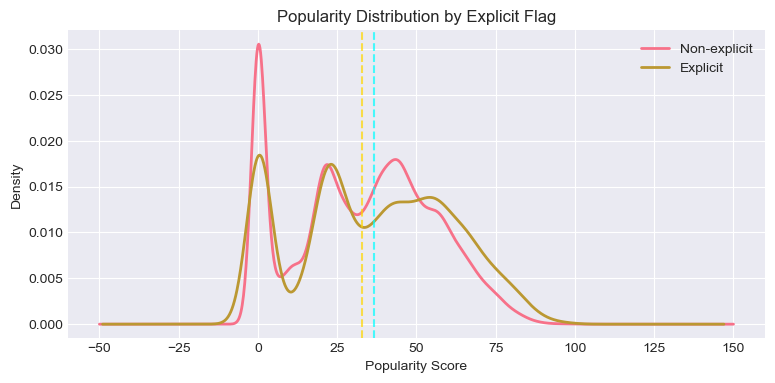

In [264]:
group_explicit=df[df['explicit'] == True]['popularity']
group_non_explicit= df[df['explicit'] == False]['popularity']
t_stat, p_val=stats.ttest_ind(group_explicit, group_non_explicit)
raw_diff=group_explicit.mean() -group_non_explicit.mean()
pooled_std =np.sqrt((group_explicit.std()**2 + group_non_explicit.std()**2) /2)
cohens_d   = raw_diff/pooled_std
print("="*50)
print(f"Non-explicit — Mean: {group_non_explicit.mean():.2f}, SD: {group_non_explicit.std():.2f}, Count: {len(group_non_explicit):,}")
print(f"Explicit — Mean: {group_explicit.mean():.2f}, SD: {group_explicit.std():.2f}, Count: {len(group_explicit):,}")
print(f"\nRaw mean difference : +{raw_diff:.4f} points")
print(f"T-statistic : {t_stat:.4f}")
print(f"p-value : {p_val:.2e}")
print(f"Cohen's d : {cohens_d:.4f}")
print("="*50)
plt.figure(figsize=(9,4))
group_non_explicit.plot.kde(linewidth=2,label='Non-explicit')
group_explicit.plot.kde(linewidth=2,label='Explicit')
plt.axvline(group_non_explicit.mean(),color='gold',linestyle='--',alpha=0.7)
plt.axvline(group_explicit.mean(),color='cyan',linestyle='--',alpha=0.7)
plt.xlabel('Popularity Score')
plt.ylabel('Density')
plt.title('Popularity Distribution by Explicit Flag')
plt.legend()
plt.show()

## 9. Multivariate Analysis: OLS Multiple Regression

In [280]:
features=['danceability', 'energy','loudness', 'speechiness','acousticness','instrumentalness','liveness', 'valence','tempo']
audio_corr_matrix=df_clean[features +['popularity']].corr()
print("="*70)
print("Correlation Matrix:")
print(audio_corr_matrix.round(2).to_string())
strong_corr_pairs=[]
for i in range(len(audio_corr_matrix.columns)):
    for j in range(i+1,len(audio_corr_matrix.columns)):
        corr_val = audio_corr_matrix.iloc[i, j]
        if abs(corr_val)>0.5:
            strong_corr_pairs.append({'Feature 1': audio_corr_matrix.columns[i],'Feature 2': audio_corr_matrix.columns[j],'Correlation': corr_val})
strong_corr_df=pd.DataFrame(strong_corr_pairs).sort_values('Correlation',key=abs,ascending=False)
print("\nStrong Feature Correlations (|r| > 0.5):")
if len(strong_corr_df) >0:
    print(strong_corr_df.round(2).to_string(index=False))
else:
    print("No strong correlations detected among features")
print("="*70)

Correlation Matrix:
                  danceability  energy  loudness  speechiness  acousticness  instrumentalness  liveness  valence  tempo  popularity
danceability              1.00    0.13      0.26         0.11         -0.17             -0.19     -0.13     0.48  -0.05        0.04
energy                    0.13    1.00      0.76         0.14         -0.73             -0.18      0.18     0.26   0.25        0.00
loudness                  0.26    0.76      1.00         0.06         -0.59             -0.43      0.08     0.28   0.21        0.05
speechiness               0.11    0.14      0.06         1.00         -0.00             -0.09      0.21     0.04   0.02       -0.04
acousticness             -0.17   -0.73     -0.59        -0.00          1.00              0.10     -0.02    -0.11  -0.21       -0.03
instrumentalness         -0.19   -0.18     -0.43        -0.09          0.10              1.00     -0.08    -0.32  -0.05       -0.10
liveness                 -0.13    0.18      0.08        

In [284]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
features=['energy', 'acousticness', 'danceability', 'valence', 'tempo']
y=df_clean['popularity']
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df_clean[features])
X_scaled= sm.add_constant(X_scaled)
ols_scaled = sm.OLS(y, X_scaled).fit()
print("\nStandardized OLS (compare feature importance)")
print(ols_scaled.summary())
X=sm.add_constant(df_clean[features])
ols=sm.OLS(y, X).fit()
print("\nUnstandardized OLS (real-world interpretation)")
print(ols.summary())


Standardized OLS (compare feature importance)
                            OLS Regression Results                            
Dep. Variable:             popularity   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     147.5
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          1.12e-156
Time:                        23:28:06   Log-Likelihood:            -5.1534e+05
No. Observations:              114000   AIC:                         1.031e+06
Df Residuals:                  113994   BIC:                         1.031e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

**Summary**
1. Non-Standardized OLS (Original Scale Model): It is being used to interpret real-world effect sizes. It answers if this feature changes in its natural unit, how much does popularity change?
- Insights & comparisons:<br>
    - Danceability (+8.88) appears dominant, but this is inflated by scale (0–1 range)<br>
    - Tempo (+0.015) looks negligible, but:<br>
    - Valence (-6.39) shows a strong negative effect in real units<br>
    - Energy (-1.29) and acousticness (-1.88) have modest negative effects<br>
2. Standardized OLS (Scaled / Z-score Model): It is being used to compare relative importance across features. It answers which feature influences popularity more when all are on equal footing?
- Insights & comparisons:<br>
    - Valence (-1.66) emerges as the strongest overall influence<br>
    - Danceability (+1.54) is a close second → strongest positive driver<br>
    - Acousticness (-0.63) has moderate influence<br>
    - Tempo (+0.45) has limited but non-zero contribution<br>
    - Energy (-0.33) is the weakest → almost negligible in comparison<br>

Unlike correlation: valence was ~0 before → now dominant→ indicates suppression / interaction effects<br>
Clear ranking: valence > danceability > acousticness > tempo > energy<br>
An R squared of 0.006 clearly depicts that the audio features could explian less than 1% variance in popularity. Hence, popularity is definitely influenced by other external features. 

## 9. Key Findings

* **Audio features show consistently weak relationships with popularity**
  * Correlation magnitudes are low across all features
  * Statistical significance does not translate into practical significance


* **Popularity is not meaningfully explained by any single audio feature**
  * No feature demonstrates strong predictive power
  * Even the strongest correlations are too small to be actionable


* **Linear relationships are negligible**
  * Pearson results indicate near-zero linear dependence
  * Suggests audio features do not scale proportionally with popularity


* **Monotonic trends are also weak**
  * Spearman correlations do not reveal strong rank-based relationships
  * Indicates lack of consistent directional trends


* **Effect sizes confirm lack of practical impact**
  * Observed relationships are too small to matter in real-world scenarios
  * Reinforces that statistical significance alone is misleading here


* **Zero-inflated popularity distribution affects analysis**
  * Large concentration of low/zero popularity tracks
  * Skews correlation strength and compresses variability


* **Redundancy and overlap exist among audio features**
  * Several features exhibit inter-correlation
  * Suggests limited independent explanatory power


* **Popularity is likely driven by non-audio factors**
  * External influences (artist reputation, marketing, platform dynamics) dominate
  * Audio characteristics alone are insufficient for explaining success


* **Univariate and bivariate analysis reach the same conclusion**
  * No hidden strong signals emerge across different analytical views
  * Reinforces robustness of the “weak signal” finding